# Cell-Cycle Scoring and Regression

In [24]:
library(Seurat)
library(tidyverse)

In [25]:
# A list of cell cycle markers, from Tirosh et al, 2015, is loaded with Seurat.  We can
# segregate this list into markers of G2/M phase and markers of S phase
s.genes <- cc.genes$s.genes
g2m.genes <- cc.genes$g2m.genes

In [26]:
FL.integrated <- readRDS("output/FL_CLL_integrated_clean.rds")

In [27]:
FL.cc <- CellCycleScoring(FL.integrated, s.features = s.genes, g2m.features = g2m.genes, set.ident = TRUE)

# view cell cycle scores and phase assignments
head(FL.cc[[]])

Warning message:
“The following features are not present in the object: TYMS, PRIM1, UHRF1, MLF1IP, RPA2, CCNE2, RAD51, RRM2, CDC45, CDC6, DSCC1, BRIP1, E2F8, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: CDK1, UBE2C, BIRC5, MKI67, FAM64A, CCNB2, CKAP2L, AURKB, BUB1, GTSE1, HJURP, HN1, CDC20, TTK, CDC25C, DLGAP5, CDCA2, KIF23, ANLN, NEK2, GAS2L3, CENPA, not searching for symbol synonyms”


,orig.ident,nCount_RNA,nFeature_RNA,integrated_snn_res.0.3,seurat_clusters,scSHM,S.Score,G2M.Score,Phase,old.ident
,<chr>,<dbl>,<int>,<fct>,<fct>,<lgl>,<dbl>,<dbl>,<chr>,<fct>
AAACCTGAGATCACGG-1_1,K1B,3273,1471,2,2,FALSE,-0.10744317,-0.07374123,G1,2
AAACCTGAGCCAGTTT-1_1,K1B,5993,1886,4,4,FALSE,-0.11282005,-0.14221581,G1,4
AAACCTGAGCGGCTTC-1_1,K1B,6318,2544,2,2,FALSE,0.08910105,-0.09270051,S,2
AAACCTGAGGCATGTG-1_1,K1B,3102,1317,0,0,FALSE,-0.10626523,-0.05108932,G1,0
AAACCTGAGTGTTTGC-1_1,K1B,2582,1179,4,4,FALSE,-0.05706729,-0.07756849,G1,4
AAACCTGCAACTGCTA-1_1,K1B,2894,1236,0,0,FALSE,0.07860304,-0.14807006,S,0


Warning message:
“Could not find MKI67 in the default search locations, found in ‘RNA’ assay instead”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Picking joint bandwidth of 0.0106

Picking joint bandwidth of 0.0078

Picking joint bandwidth of 0.00496

Picking joint bandwidth of 1.26e-06



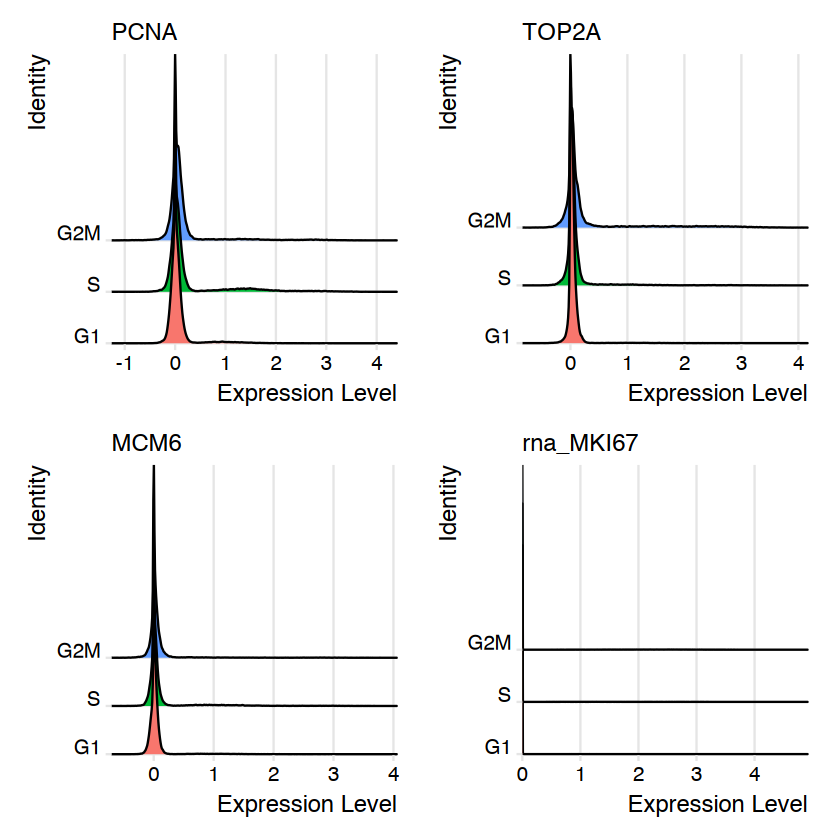

In [28]:
# Visualize the distribution of cell cycle markers across
RidgePlot(FL.cc, features = c("PCNA", "TOP2A", "MCM6", "MKI67"), ncol = 2)

Warning message in PrepDR(object = object, features = features, verbose = verbose):
“The following 35 features requested have not been scaled (running reduction without them): TYMS, PRIM1, UHRF1, MLF1IP, RPA2, CCNE2, RAD51, RRM2, CDC45, CDC6, DSCC1, BRIP1, E2F8, CDK1, UBE2C, BIRC5, MKI67, FAM64A, CCNB2, CKAP2L, AURKB, BUB1, GTSE1, HJURP, HN1, CDC20, TTK, CDC25C, DLGAP5, CDCA2, KIF23, ANLN, NEK2, GAS2L3, CENPA”
Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
PC_ 1 
Positive:  BLM, CASP8AP2, UBR7, UNG, LBR, POLA1, TIPIN, MSH2, G2E3, WDR76 
	   CHAF1B, MCM5, RFC2, CDCA7, RANGAP1, CTCF, MCM2, SLBP, EXO1, MCM6 
	   POLD3, DTL, NASP, USP1, HELLS, KIF20B, CBX5, NCAPD2, CKAP2, CKAP5 
Negative:  CENPF, NUF2, CDCA8, CDCA3, CKS1B, TPX2, TOP2A, NUSAP1, HMMR, HMGB2 
	   CENPE, CLSPN, TUBB4B, AURKA, PSRC1, FEN1, KIF2C, SMC4, CKS2, ANP32E 
	   RAD51AP1, TMPO, KIF11, NDC80, ATAD2, MCM4, 

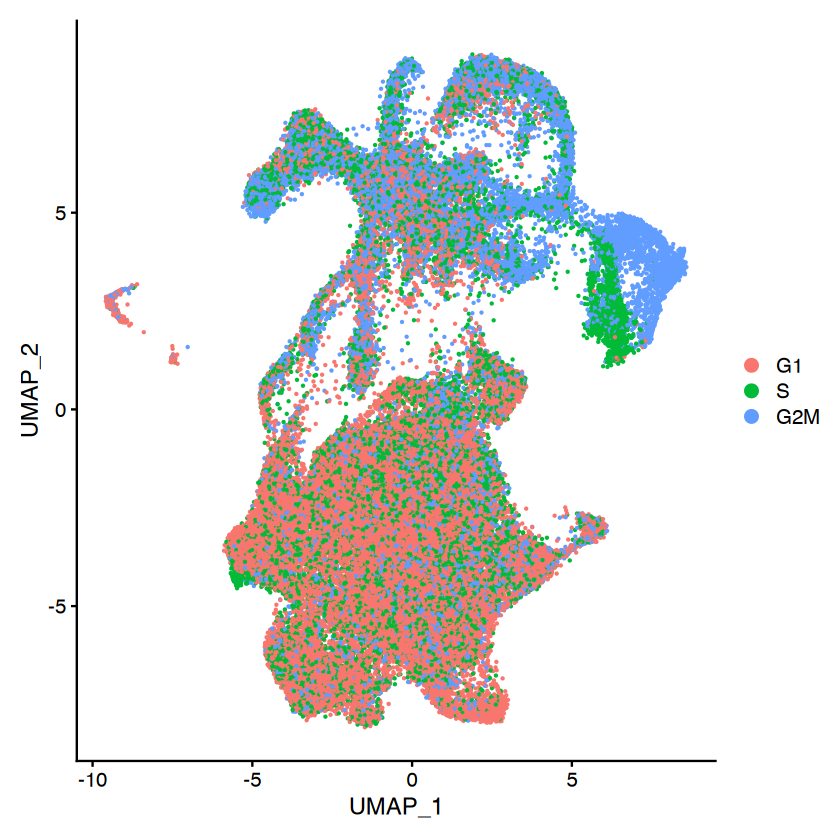

In [29]:
# Running a PCA on cell cycle genes reveals, unsurprisingly, that cells separate entirely by
# phase
FL.cc.pca <- RunPCA(FL.cc, features = c(s.genes, g2m.genes))
DimPlot(FL.cc.pca, raster=FALSE)

In [30]:
cell_cycle <- as.data.frame(FL.cc[[]]) %>% tibble::rownames_to_column("cell") %>% mutate(cell = gsub(".{4}$", "", cell))

In [31]:
#write.csv(cell_cycle, "output/FL_cell_cycle.csv", row.names=FALSE)

In [32]:
cell_cycle <- read.csv("output/FL_cell_cycle.csv")

In [33]:
### Load df with filtered SHMss events (trully positive)
df_summary <- read.csv("output/df_summary_K12345678_v3.csv")

In [34]:
pos_cells <- df_summary %>% mutate(orig.ident = str_sub(subject, 1, 3), group = "SHMss_observed") %>% select(orig.ident,cell,group) %>% unique() %>% filter(orig.ident %in% c("K6B", "K7B", "K8B"))
head(pos_cells)

,orig.ident,cell,group
,<chr>,<chr>,<chr>
1,K6B,CTGAAGTAGTTTAGGA,SHMss_observed
2,K6B,ACTGAGTTCTACTTAC,SHMss_observed
3,K6B,GACCAATTCAGCATGT,SHMss_observed
4,K6B,ACGATACAGGAGCGAG,SHMss_observed
5,K6B,ACTGTCCCATCTGGTA,SHMss_observed
6,K6B,ATCTACTGTATAGTAG,SHMss_observed


In [35]:
my_cells <- read.csv("output/reference_cells_k6-8.csv") %>% dplyr::select(experiment,cell) %>% 
mutate(group= "SHMss_not_observed") %>%
rename(orig.ident=experiment) %>% mutate(orig.ident = paste0(orig.ident, 'B')) %>% unique() %>% bind_rows(pos_cells)

In [36]:
str(my_cells)

'data.frame':	14068 obs. of  3 variables:
 $ orig.ident: chr  "K6B" "K6B" "K6B" "K6B" ...
 $ cell      : chr  "AAACCTGAGACCGGAT" "AAACCTGAGGATGCGT" "AAACCTGAGGGTTTCT" "AAACCTGCAAGGCTCC" ...
 $ group     : chr  "SHMss_not_observed" "SHMss_not_observed" "SHMss_not_observed" "SHMss_not_observed" ...


In [37]:
my_cells_f <- my_cells %>%
  anti_join(pos_cells, by = c("orig.ident","cell"))

In [38]:
str(my_cells_f)

'data.frame':	13458 obs. of  3 variables:
 $ orig.ident: chr  "K6B" "K6B" "K6B" "K6B" ...
 $ cell      : chr  "AAACCTGAGACCGGAT" "AAACCTGAGGATGCGT" "AAACCTGAGGGTTTCT" "AAACCTGCAAGGCTCC" ...
 $ group     : chr  "SHMss_not_observed" "SHMss_not_observed" "SHMss_not_observed" "SHMss_not_observed" ...


In [39]:
head(my_cells)

,orig.ident,cell,group
,<chr>,<chr>,<chr>
1,K6B,AAACCTGAGACCGGAT,SHMss_not_observed
2,K6B,AAACCTGAGGATGCGT,SHMss_not_observed
3,K6B,AAACCTGAGGGTTTCT,SHMss_not_observed
4,K6B,AAACCTGCAAGGCTCC,SHMss_not_observed
5,K6B,AAACCTGCAATCCAAC,SHMss_not_observed
6,K6B,AAACCTGCACGGTGTC,SHMss_not_observed


In [40]:
table(my_cells$group)


SHMss_not_observed     SHMss_observed 
             13763                305 

In [41]:
FL_cc <- inner_join(cell_cycle, my_cells) #%>% unique()
head(FL_cc)

Joining with `by = join_by(cell, orig.ident)`


,cell,orig.ident,nCount_RNA,nFeature_RNA,S.Score,G2M.Score,Phase,old.ident,group
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,AAACCTGAGACCGGAT,K6B,5023,2155,0.01991264,-0.15749657,S,K6B,SHMss_not_observed
2,AAACCTGAGGATGCGT,K6B,4214,1912,-0.01466639,-0.15125706,G1,K6B,SHMss_not_observed
3,AAACCTGAGGGTTTCT,K6B,3589,1736,-0.01562322,-0.10520217,G1,K6B,SHMss_not_observed
4,AAACCTGCAAGGCTCC,K6B,2848,1366,0.04042885,-0.09636299,S,K6B,SHMss_not_observed
5,AAACCTGCAATCCAAC,K6B,2997,1400,0.03695621,-0.01397120,S,K6B,SHMss_not_observed
6,AAACCTGCACGGTGTC,K6B,2406,1256,-0.03488921,-0.14327019,G1,K6B,SHMss_not_observed


- Transcriptional events during S-phase are critical for cell cycle progression. Here, by using a nascent RNA capture assay coupled with high-throughput sequencing, we determined the temporal patterns of transcriptional events that occur during S-phase.
- During the G1 phase, cells accomplish most of their growth. They get bigger in size and make proteins and organelles needed for normal functions of DNA synthesis. Here, proteins and RNAs are synthesized, and, more especially the centromere and the other components of the centrosomes are made

In [42]:
FL_cc %>% filter( group == "SHMss_observed") %>%  select(Phase) %>% table()

Phase
 G1 G2M   S 
238  24  43 

In [43]:
FL_cc %>% filter( group == "SHMss_not_observed") %>%  select(Phase) %>% table()

Phase
   G1   G2M     S 
10403   852  2508 

In [44]:
FL_cc_summary <- FL_cc %>% group_by(group, Phase) %>% count() %>% group_by(group) %>% mutate(percentage= n * 100 / sum(n))
FL_cc_summary

group,Phase,n,percentage
<chr>,<chr>,<int>,<dbl>
SHMss_not_observed,G1,10403,75.586718
SHMss_not_observed,G2M,852,6.190511
SHMss_not_observed,S,2508,18.222771
SHMss_observed,G1,238,78.032787
SHMss_observed,G2M,24,7.868852
SHMss_observed,S,43,14.098361


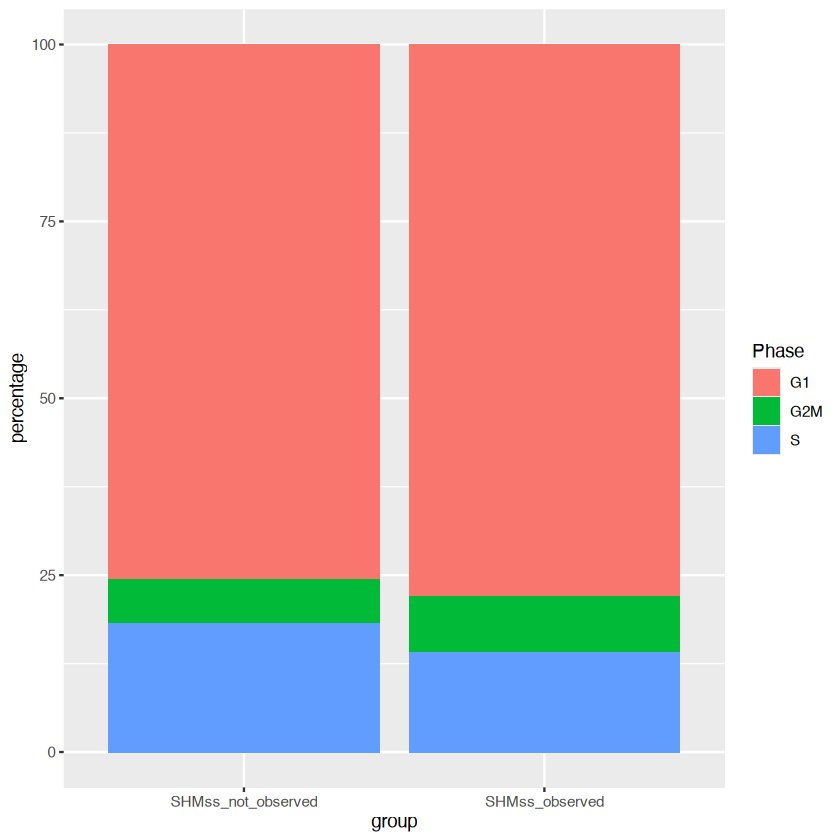

In [45]:
# Use position=position_dodge()
ggplot(data=FL_cc_summary, aes(x=group, y=percentage, fill=Phase)) +
geom_bar(stat="identity")